In [2]:
import pandas as pd
clientes = pd.read_json('/content/drive/MyDrive/DATASCIENCE/TelecomX_Data.json')

In [3]:
from pandas import json_normalize
clientes = json_normalize(clientes.to_dict(orient = 'records'))
#Se realiza la normalizacion para desanidar columnas

In [4]:
clientes.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [5]:
#Renombrar columnas para quitar los puntos
clientes.columns = clientes.columns.str.replace('.','_')

In [6]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [7]:
#Convierte a numerico
clientes['account_Charges_Total'] = pd.to_numeric(
    clientes['account_Charges_Total'],
    errors = 'coerce'
)

In [8]:
clientes.isnull().sum()

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


In [9]:
clientes[clientes["account_Charges_Total"].isnull()][
    ["customer_tenure", "account_Charges_Monthly"]
]

,customer_tenure,account_Charges_Monthly
975,0,56.05
1775,0,20.00
1955,0,61.90
2075,0,19.70
2232,0,20.25
2308,0,25.35
2930,0,73.35
3134,0,25.75
3203,0,52.55
4169,0,80.85


In [11]:
clientes["account_Charges_Total"] = clientes["account_Charges_Total"].fillna(0)

In [12]:
#ELIMINACION DE COLUMNAS INNECESARIAS O SIN VALOR PARA EL MODELO

In [13]:
clientes.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [15]:
clientes.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total'],
      dtype='object')

In [16]:
clientes = clientes.drop('customerID', axis = 1)

In [17]:
clientes.columns

Index(['Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total'],
      dtype='object')

In [19]:
#CONVERTIR VARIABLES CATEGORICAS
clientes.dtypes

,0
Churn,object
customer_gender,object
customer_SeniorCitizen,int64
customer_Partner,object
customer_Dependents,object
customer_tenure,int64
phone_PhoneService,object
phone_MultipleLines,object
internet_InternetService,object
internet_OnlineSecurity,object


In [23]:
clientes = pd.get_dummies(clientes, drop_first=True)
clientes.head()

,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,Churn_No,Churn_Yes,customer_gender_Male,customer_Partner_Yes,customer_Dependents_Yes,phone_PhoneService_Yes,...,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0,9,65.6,593.30,True,False,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,True,False,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,False,True,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,False,True,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,False,True,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


In [25]:
clientes.dtypes.value_counts()

,count
bool,28
int64,2
float64,2


In [26]:
clientes.columns

Index(['customer_SeniorCitizen', 'customer_tenure', 'account_Charges_Monthly',
       'account_Charges_Total', 'Churn_No', 'Churn_Yes',
       'customer_gender_Male', 'customer_Partner_Yes',
       'customer_Dependents_Yes', 'phone_PhoneService_Yes',
       'phone_MultipleLines_No phone service', 'phone_MultipleLines_Yes',
       'internet_InternetService_Fiber optic', 'internet_InternetService_No',
       'internet_OnlineSecurity_No internet service',
       'internet_OnlineSecurity_Yes',
       'internet_OnlineBackup_No internet service',
       'internet_OnlineBackup_Yes',
       'internet_DeviceProtection_No internet service',
       'internet_DeviceProtection_Yes',
       'internet_TechSupport_No internet service', 'internet_TechSupport_Yes',
       'internet_StreamingTV_No internet service', 'internet_StreamingTV_Yes',
       'internet_StreamingMovies_No internet service',
       'internet_StreamingMovies_Yes', 'account_Contract_One year',
       'account_Contract_Two year', 'acc

In [27]:
clientes['Churn_Yes'].value_counts(normalize=True)

,proportion
Churn_Yes,
False,0.74281
True,0.25719


In [29]:
corr_matrix = clientes.corr()

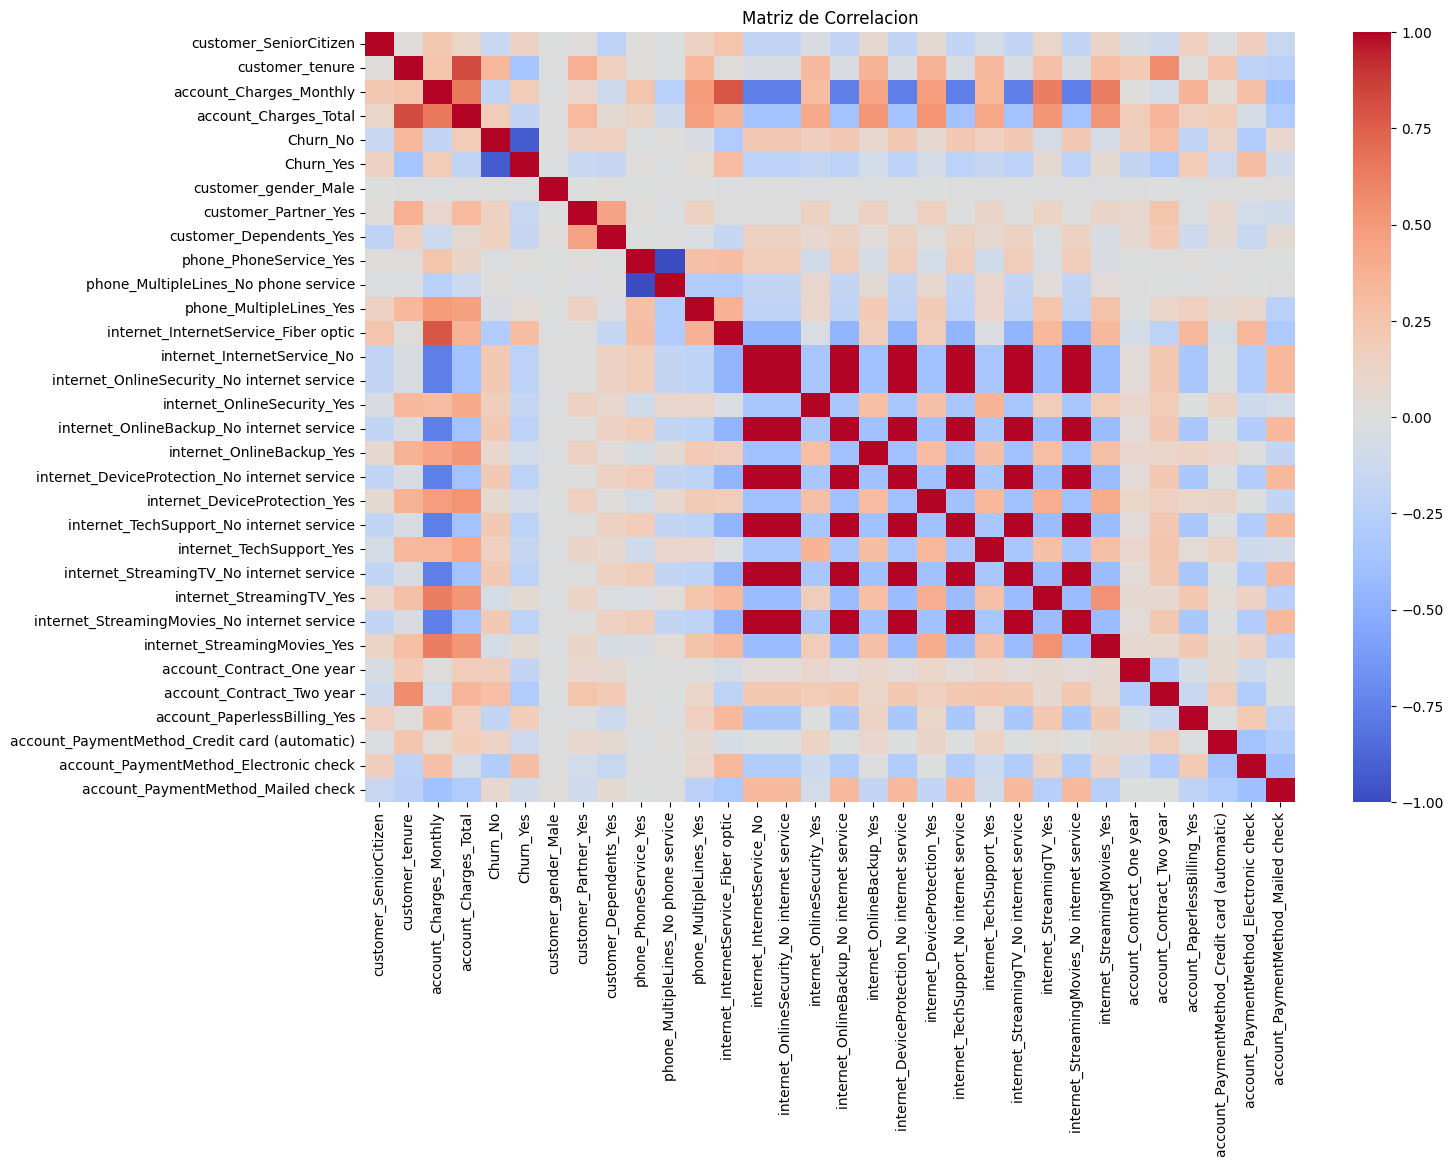

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, cmap = 'coolwarm', center = 0)
plt.title('Matriz de Correlacion')
plt.show()

In [31]:
corr_with_churn = corr_matrix["Churn_Yes"].sort_values(ascending=False)
corr_with_churn

,Churn_Yes
Churn_Yes,1.000000
internet_InternetService_Fiber optic,0.300949
account_PaymentMethod_Electronic check,0.294626
account_Charges_Monthly,0.189866
account_PaperlessBilling_Yes,0.186666
customer_SeniorCitizen,0.146733
internet_StreamingTV_Yes,0.062430
internet_StreamingMovies_Yes,0.060586
phone_MultipleLines_Yes,0.039343
phone_PhoneService_Yes,0.012571


In [32]:
#Es redundante tener CHURN SI Y CHURN NO
clientes = clientes.drop('Churn_No', axis = 1)

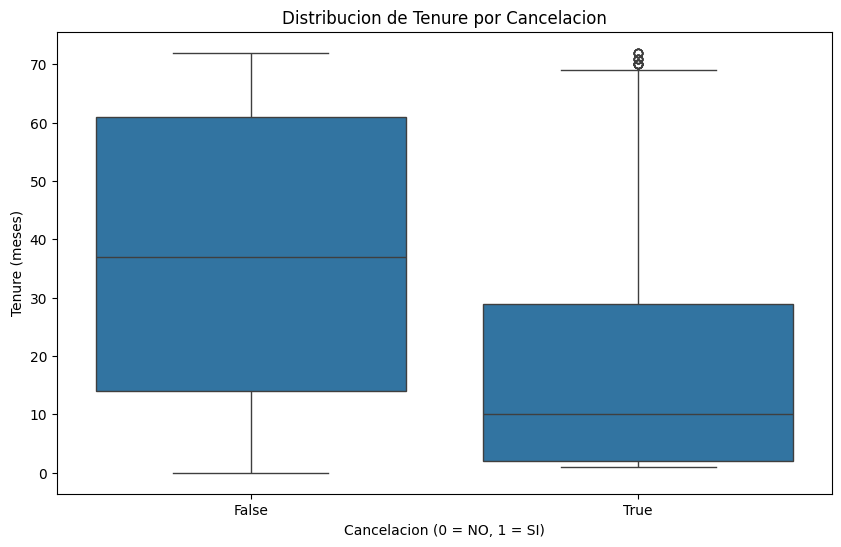

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot( x = clientes['Churn_Yes'], y = clientes['customer_tenure'])
plt.xlabel('Cancelacion (0 = NO, 1 = SI)')
plt.ylabel('Tenure (meses)')
plt.title('Distribucion de Tenure por Cancelacion')
plt.show()

A menor antiguedad es mas probable la cancelacion

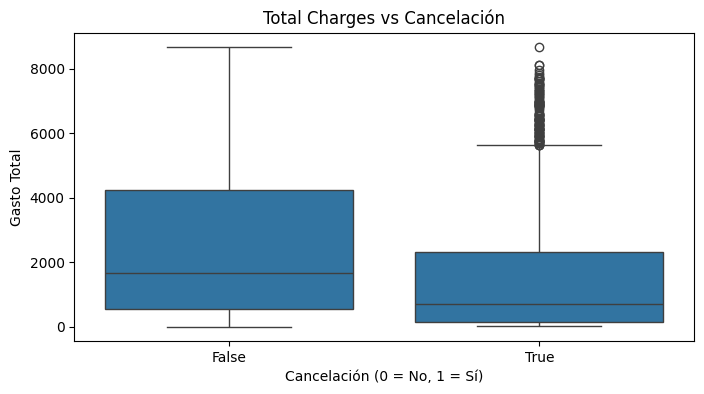

In [35]:
plt.figure(figsize=(8,4))
sns.boxplot(x=clientes["Churn_Yes"], y=clientes["account_Charges_Total"])
plt.xlabel("Cancelación (0 = No, 1 = Sí)")
plt.ylabel("Gasto Total")
plt.title("Total Charges vs Cancelación")
plt.show()

In [36]:
 x = clientes.drop('Churn_Yes', axis = 1)
 y = clientes['Churn_Yes']


In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42, stratify = y)
#Stratify mantiene proporciones de CHURN en train y test

In [39]:
y_train.value_counts(normalize = True)
y_test.value_counts(normalize = True)

,proportion
Churn_Yes,
False,0.742779
True,0.257221


In [40]:
#MODELOS
#Para modelo de regresion es importante normalizar
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
#Importamos modelo de regresion logistica
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000,random_state =42)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [42]:
#Predicciones
y_pred_log = log_model.predict(X_test_scaled)

In [46]:
#Evaluaciones
from sklearn.metrics import classification_report, confusion_matrix
print('Regresion Logistica')
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Regresion Logistica
[[964 116]
 [173 201]]
              precision    recall  f1-score   support

       False       0.85      0.89      0.87      1080
        True       0.63      0.54      0.58       374

    accuracy                           0.80      1454
   macro avg       0.74      0.72      0.73      1454
weighted avg       0.79      0.80      0.80      1454



In [48]:
#RANDOM FOREST -> No requiere normalizacion porque no es de distancias
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators = 100, random_state=42)
rf_model.fit(X_train,y_train)


RandomForestClassifier(random_state=42)

In [49]:
#Preddiciones
y_pred_rf = rf_model.predict(X_test)

In [51]:
#Evaluacion
print('Random Forest')
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
[[961 119]
 [198 176]]
              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1080
        True       0.60      0.47      0.53       374

    accuracy                           0.78      1454
   macro avg       0.71      0.68      0.69      1454
weighted avg       0.77      0.78      0.77      1454



In [54]:
#DataFrame con importancia de las variables de modelo
importances = pd.DataFrame({
    "Variable": x.columns,
    "Importancia": rf_model.feature_importances_
})

importances = importances.sort_values("Importancia", ascending=False)

importances.head(10)

,Variable,Importancia
3,account_Charges_Total,0.195570
2,account_Charges_Monthly,0.171988
1,customer_tenure,0.170463
10,internet_InternetService_Fiber optic,0.038524
28,account_PaymentMethod_Electronic check,0.035305
4,customer_gender_Male,0.029426
25,account_Contract_Two year,0.028434
13,internet_OnlineSecurity_Yes,0.027320
26,account_PaperlessBilling_Yes,0.026202
19,internet_TechSupport_Yes,0.024537


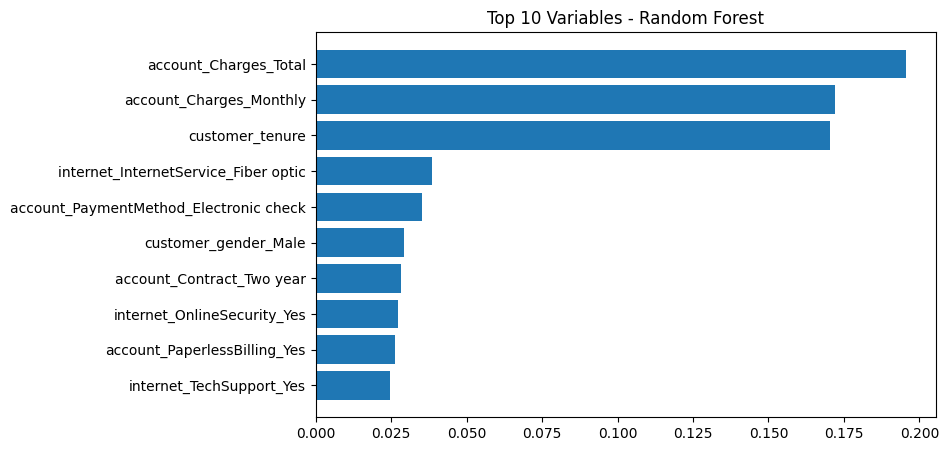

In [55]:
import matplotlib.pyplot as plt

top10 = importances.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["Variable"], top10["Importancia"])
plt.gca().invert_yaxis()
plt.title("Top 10 Variables - Random Forest")
plt.show()

#PARA ESTE MODELO ACCOUNT_CHARGES_TOTAL ES QUIEN MEJOR EXPLICA EL MODELO


In [56]:
import pandas as pd

coef_df = pd.DataFrame({
    "Variable": x.columns,
    "Coeficiente": log_model.coef_[0]
})

coef_df["Abs"] = coef_df["Coeficiente"].abs()
coef_df = coef_df.sort_values("Abs", ascending=False)

coef_df.head(10)

,Variable,Coeficiente,Abs
1,customer_tenure,-1.429650,1.429650
3,account_Charges_Total,0.682484,0.682484
10,internet_InternetService_Fiber optic,0.600216,0.600216
2,account_Charges_Monthly,-0.576439,0.576439
25,account_Contract_Two year,-0.543088,0.543088
24,account_Contract_One year,-0.257022,0.257022
26,account_PaperlessBilling_Yes,0.190420,0.190420
21,internet_StreamingTV_Yes,0.183173,0.183173
23,internet_StreamingMovies_Yes,0.172532,0.172532
28,account_PaymentMethod_Electronic check,0.162553,0.162553


#PARA ESTE MODELO LA VARIABLE QUE MEJOR EXPLICA EL MODELO ES CUSTOMER_TENURE

#Las variables más determinantes para la cancelación son:

-Antigüedad del cliente (tenure)

-Tipo de contrato

-Tipo de internet

-Cargos acumulados y mensuales

-Método de pago (electronic check)

#El churn está principalmente asociado a:

-Clientes nuevos

-Contratos mensuales

-Servicios de mayor costo

-Ciertos métodos de pago

#Regresión Logística

-Accuracy: 0.80

-Recall (Churn=True): 0.54

-F1-score (Churn=True): 0.58

#Random Forest

-Accuracy: 0.78

-Recall (Churn=True): 0.47

-F1-score (Churn=True): 0.53

#1. Retención temprana (primeros 6–12 meses)

-Dado que la antigüedad es el factor más fuerte:

-Implementar seguimiento personalizado a clientes nuevos.

-Ofrecer incentivos en los primeros meses.

-Programas de onboarding estructurado.

#2. Incentivar contratos largos

-Descuentos progresivos por contratos de 1 o 2 años.

-Beneficios exclusivos para renovación anual.

-Penalizaciones suaves para migrar de mensual a anual.

#3. Intervenir en clientes con fibra óptica

-Dado su mayor tasa de churn:

-Evaluar percepción de precio.

-Mejorar soporte técnico.

-Ofrecer paquetes complementarios.